In [1]:
import os
import sys
import gc
os.chdir('/zhome/71/c/146676/texture_tomography')
sys.path.append('/zhome/71/c/146676/texture_tomography/package/odf_mumott')
import h5py
import numpy as np

from package.cil_addons.texture_tomography.operators.pfo_and_projection_batched_opencl import PFO_OPENCL_BATCHED

import matplotlib.pyplot as plt
from multiprocessing import Pool
import yaml

# Import your lattice functions
from package.utils.lattice import cubic, tetragonal, orthorhombic, hexagonal, trigonal_rhombohedral, monoclinic, triclinic
from package.utils.coordinates import get_probed_coordinates

from package.odf_mumott.odftt.texture import grids, point_groups, odfs
from package.odf_mumott.odftt.crystallography import cubic


from package.cil_addons.texture_tomography.optimization.fista_opencl import FISTAOpenCL
import pyopencl.array as clarray

from orix import plot, sampling
from orix.crystal_map import Phase
from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d

INFO:Setting the number of threads to 8. If your physical cores are fewer than this number, you may want to use numba.set_num_threads(n), and os.environ["OPENBLAS_NUM_THREADS"] = f"{n}" to set the number of threads to the number of physical cores n.
INFO:Setting numba log level to WARNING.


In [2]:
config_path = "configs/aluminum_config_small.yaml"

with open(config_path, 'r') as f:
    cfg = yaml.safe_load(f)

grid_resolution_parameter = cfg['grid_resolution_parameter']
kernel_sigma = cfg['kernel_sigma']
N_theta = cfg['N_theta']
min_two_theta = cfg['min_two_theta']
N_chi = cfg['N_chi']
N_rot = cfg['N_rot']
Nx = cfg['Nx']
Ny = cfg['Ny']
peak_width = cfg['peak_width']
datapath = cfg["datapath"]
filename_integrated = cfg["integrated_file"]
cif_path = cfg["cif_path"]
#reflections_folder = cfg["reflections_folder"]
cor_offset = cfg["cor_offset"]
N_seg = N_theta*N_chi


In [3]:
datapath_ = '/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/raw_data_aluminum_rod/'


N_workers = 16  # adjust to match available CPUs

# --- Get list of dataset keys (exclude metadata) ---
filename = datapath_ + 'pilatus_integrated_re_anglemean_x10.h5'
with h5py.File(filename, 'r') as f:
    keys = [k for k in f.keys() if k != 'two_theta']

    keys = sorted(keys, key=lambda x: int(x))
    keys = keys[::]

with h5py.File(filename, 'r') as f:
    two_theta = f['two_theta'][:]

# --- Worker function ---
def load_single(key):
    with h5py.File(filename, 'r') as f:
        arr = f[key][...]
    return arr

with Pool(processes=N_workers) as pool:
    data_list = pool.map(load_single, keys)

all_data = np.stack(data_list,axis=0)
all_data_reshaped = all_data.reshape((N_rot, Nx, N_seg))

In [ ]:
op = PFO_OPENCL_BATCHED(
        cfg = cfg,
        two_thetas = two_theta,
        verbose=False)

queue = op.queue
Nx, Ny, K = op.Nx, op.Nx, op.K_sum

x0_gpu = clarray.zeros(
    queue,
    (Nx, Ny, K),
    dtype=np.float32,
    order="F",
)

out_cpu = np.ascontiguousarray(
    all_data_reshaped,
    dtype=np.float32
)
out_gpu = clarray.to_device(queue, out_cpu)
assert out_gpu.flags.c_contiguous
op.set_pf_batch_max_gb(2.0)
# l1 constant: 1e7
# tv constant: 1e-5
# L constant for l1: 5e11
solver = FISTAOpenCL(op, prox_kind="nonneg_tv", lam=1e-5, L=1e12)


x_sol_gpu = solver.run(x0_gpu, out_gpu, niter=20, verbose=1, diagnostics_interval=1)
coeffs = x_sol_gpu.get().transpose((0,1,2))
op.free_memory()
del x_sol_gpu
del out_gpu
del x0_gpu
gc.collect()

[iter    1/20] obj=1.445826e+13  f=1.445826e+13  g=0.000000e+00  ||x||=9.057030e-02  ||grad||=9.595234e+10  tau=1.000e-12  beta=0.000e+00
[iter    2/20] obj=1.383689e+13  f=1.383689e+13  g=0.000000e+00  ||x||=1.361721e-01  ||grad||=5.911786e+10  tau=1.000e-12  beta=2.818e-01
[iter    3/20] obj=1.359308e+13  f=1.359308e+13  g=0.000000e+00  ||x||=1.721140e-01  ||grad||=4.540043e+10  tau=1.000e-12  beta=4.340e-01
[iter    4/20] obj=1.345957e+13  f=1.345957e+13  g=0.000000e+00  ||x||=2.024359e-01  ||grad||=4.106057e+10  tau=1.000e-12  beta=5.311e-01
[iter    5/20] obj=1.336185e+13  f=1.336185e+13  g=0.000000e+00  ||x||=2.304167e-01  ||grad||=3.900080e+10  tau=1.000e-12  beta=5.988e-01
[iter    6/20] obj=1.328278e+13  f=1.328278e+13  g=0.000000e+00  ||x||=2.575684e-01  ||grad||=3.772878e+10  tau=1.000e-12  beta=6.489e-01
[iter    7/20] obj=1.321527e+13  f=1.321527e+13  g=0.000000e+00  ||x||=2.842599e-01  ||grad||=3.684003e+10  tau=1.000e-12  beta=6.876e-01
[iter    8/20] obj=1.315547e+13  f

0

In [9]:
# x_test = np.zeros((Nx, Ny, K), np.float32, order="F")
# x_test[Nx//4:3*Nx//4, Ny//4:3*Ny//4, :] = 1.0
# x_test += 0.1 * np.random.randn(Nx, Ny, K).astype(np.float32)

# x_gpu = clarray.to_device(queue, x_test)

# from package.cil_addons.texture_tomography.optimization.prox_tv import (
#     TVProxKernels,
#     prox_tv_nonneg_inplace,
# )

# tv_kernels = TVProxKernels(op.ctx)

# # allocate buffers ONCE
# buffers = {
#     "y":  clarray.empty(queue, x_gpu.shape, np.float32, order="F"),
#     "gx": clarray.zeros(queue, x_gpu.shape, np.float32, order="F"),
#     "gy": clarray.zeros(queue, x_gpu.shape, np.float32, order="F"),
#     "px": clarray.zeros(queue, x_gpu.shape, np.float32, order="F"),
#     "py": clarray.zeros(queue, x_gpu.shape, np.float32, order="F"),
#     "div": clarray.zeros(queue, x_gpu.shape, np.float32, order="F"),
# }

# lam = 1e-3        # START SMALL
# tau = 0.25        # prox step (not FISTA tau)
# n_iter = 1000       # enough to converge prox
# for lam in [1e-4, 1e-3, 1e-2,1e0]:
#     x_tmp = clarray.to_device(queue, x_test)
#     prox_tv_nonneg_inplace(
#         queue=queue,
#         kernels=tv_kernels,
#         x_gpu=x_gpu,
#         y_gpu=buffers["y"],
#         ux=buffers["gx"],
#         uy=buffers["gy"],
#         px=buffers["px"],
#         py=buffers["py"],
#         div=buffers["div"],
#         weight=lam,
#         tau=tau,
#         n_iter=n_iter,
#     )
#     queue.finish()


#     x_tv = x_gpu.get()

#     import matplotlib.pyplot as plt

#     k = 0
#     plt.figure(figsize=(12,4))
#     plt.subplot(1,3,1)
#     plt.title("Before")
#     plt.imshow(x_test[:,:,k], cmap="gray")
#     plt.colorbar()

#     plt.subplot(1,3,2)
#     plt.title("After TV")
#     plt.imshow(x_tv[:,:,k], cmap="gray")
#     plt.colorbar()

#     plt.subplot(1,3,3)
#     plt.title("Difference")
#     plt.imshow(x_tv[:,:,k] - x_test[:,:,k], cmap="bwr")
#     plt.colorbar()
#     plt.show()


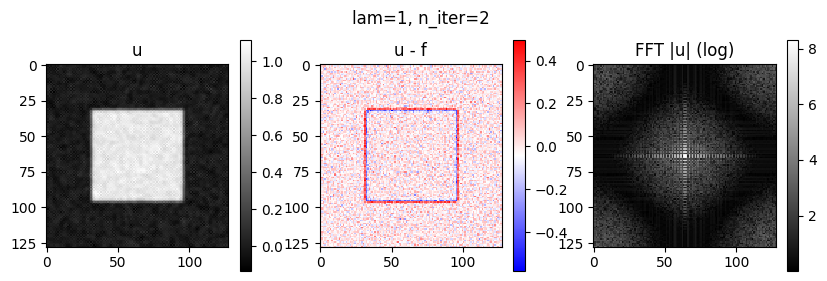

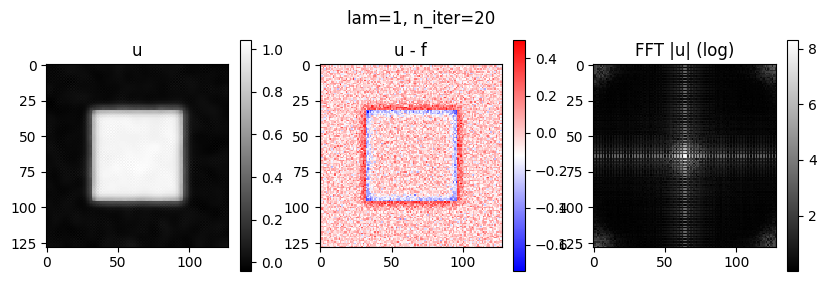

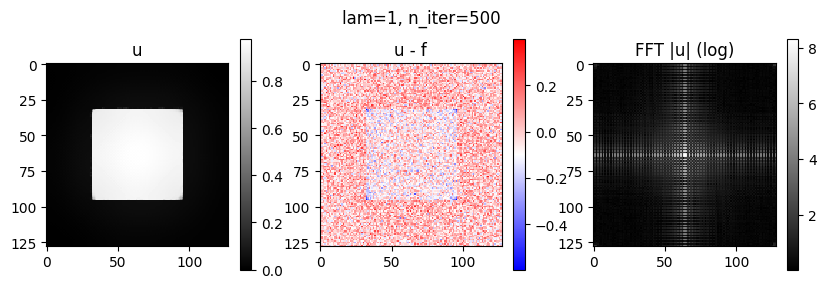

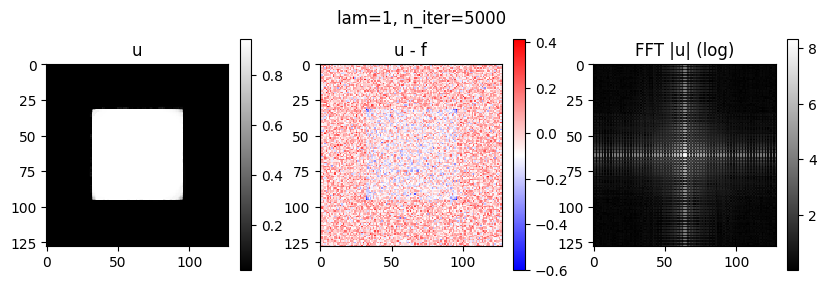

In [10]:
import numpy as np


def tv_denoise_chambolle_2d(f, weight, n_iter=200):
    """
    Chambolle TV denoising (2D), equivalent to skimage.
    """
    f = f.astype(np.float32, copy=False)
    Nx, Ny = f.shape

    # dual variables
    px = np.zeros_like(f)
    py = np.zeros_like(f)

    tau = 0.25  # = 1 / (2 * ndim)

    for _ in range(n_iter):
        # --- compute divergence of p ---
        div_p = np.zeros_like(f)
        div_p[:-1, :] -= px[:-1, :]
        div_p[1:,  :] += px[:-1, :]
        div_p[:, :-1] -= py[:, :-1]
        div_p[:, 1: ] += py[:, :-1]

        # --- primal update (derived, not stored) ---
        u = f - div_p

        # --- gradient of u ---
        ux = np.zeros_like(f)
        uy = np.zeros_like(f)
        ux[:-1, :] = u[1:, :] - u[:-1, :]
        uy[:, :-1] = u[:, 1:] - u[:, :-1]

        # --- dual ascent ---
        px += tau * ux
        py += tau * uy

        # --- projection onto |p| <= weight ---
        norm = np.sqrt(px**2 + py**2)
        denom = np.maximum(1.0, norm / weight)
        px /= denom
        py /= denom

    # final primal
    div_p = np.zeros_like(f)
    div_p[:-1, :] -= px[:-1, :]
    div_p[1:,  :] += px[:-1, :]
    div_p[:, :-1] -= py[:, :-1]
    div_p[:, 1: ] += py[:, :-1]

    u = f - div_p
    return u






import matplotlib.pyplot as plt

Nx, Ny = 128, 128

x_test = np.zeros((Nx, Ny), np.float32)
x_test[Nx//4:3*Nx//4, Ny//4:3*Ny//4] = 1.0
x_test += 0.1 * np.random.randn(Nx, Ny).astype(np.float32)


lam = 1  # your "cranked" value
for n_iter in [2, 20, 500, 5000]:
    u = tv_denoise_chambolle_2d(x_test.astype(np.float64), weight=lam, n_iter=n_iter)

    plt.figure(figsize=(10,3))
    plt.suptitle(f"lam={lam}, n_iter={n_iter}")

    plt.subplot(1,3,1)
    plt.title("u")
    plt.imshow(u, cmap="gray", interpolation="nearest")
    plt.colorbar()

    plt.subplot(1,3,2)
    plt.title("u - f")
    plt.imshow(u - x_test, cmap="bwr", interpolation="nearest")
    plt.colorbar()

    plt.subplot(1,3,3)
    plt.title("FFT |u| (log)")
    F = np.fft.fftshift(np.fft.fft2(u))
    plt.imshow(np.log1p(np.abs(F)), cmap="gray", interpolation="nearest")
    plt.colorbar()

    plt.show()



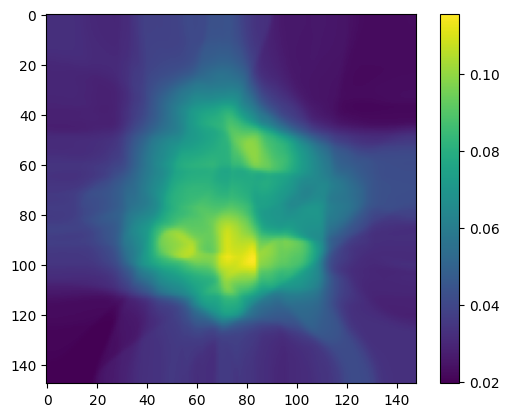

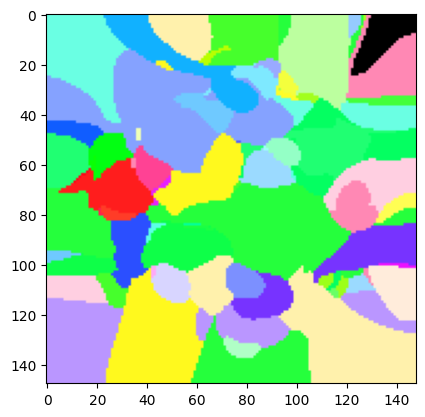

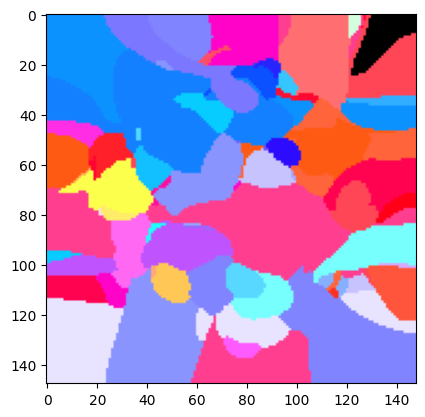

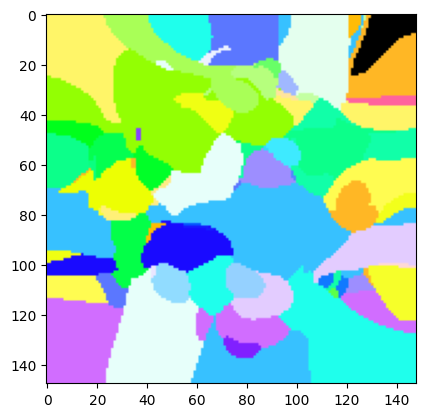

In [11]:
grid = op.grid_list[0]

plt.imshow(coeffs.sum(axis=2))
plt.colorbar()
plt.show()

IVP_map_direction = [1,0,0]
ipfkey = plot.IPFColorKeyTSL(symmetry.Oh, direction=Vector3d(IVP_map_direction))
orientations = Orientation.from_scipy_rotation(grid)
orientations.symmetry = ipfkey.symmetry
rgb_z = ipfkey.orientation2color(orientations)[np.argmax(coeffs, axis = -1)]
mask = coeffs.sum(axis=2)>0.02
rgb_z[~mask] *= 0
plt.imshow(rgb_z[::-1, ::-1])
plt.show()

IVP_map_direction = [0,1,0]
ipfkey = plot.IPFColorKeyTSL(symmetry.Oh, direction=Vector3d(IVP_map_direction))
orientations = Orientation.from_scipy_rotation(grid)
orientations.symmetry = ipfkey.symmetry
rgb_z = ipfkey.orientation2color(orientations)[np.argmax(coeffs, axis = -1)]
mask = coeffs.sum(axis=2)>0.02
rgb_z[~mask] *= 0
plt.imshow(rgb_z[::-1, ::-1])
plt.show()

IVP_map_direction = [0,0,1]
ipfkey = plot.IPFColorKeyTSL(symmetry.Oh, direction=Vector3d(IVP_map_direction))
orientations = Orientation.from_scipy_rotation(grid)
orientations.symmetry = ipfkey.symmetry
rgb_z = ipfkey.orientation2color(orientations)[np.argmax(coeffs, axis = -1)]
mask = coeffs.sum(axis=2)>0.02
rgb_z[~mask] *= 0
plt.imshow(rgb_z[::-1, ::-1])
plt.show()